# Reconstruct the Stanford Bunny

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
from tqdm.notebook import trange
import k3d
import sys
import os
import time
import copy
import trimesh
import mesh_to_sdf
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from models.model_architecture import PlaceholderNet, GeneralNet
from training.optimizers import GaussNewton, GaussNewtonNew
from util.surface_sampling import sample_model_surface_binsearch, sample_model_surface_newton 
from util.error_metrics import chamfer_div, compute_distance 
from util.visualization.utils_mesh import get_mesh

torch.manual_seed(0)


device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [27]:
mesh = trimesh.load("bun_zipper_res3.ply")
pts = 9*torch.tensor(mesh.vertices, dtype=torch.float64) + torch.tensor([0.1, -1, 0], dtype=torch.float64)
fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(mesh.vertices, mesh.faces, color=0xbbbbbb, side='double', flat_shading=False)

fig.display()

Output()

In [28]:
"""Load the model"""
# model = PlaceholderNet(ks=[3, 128, 128, 128, 1], act=torch.sin)
# model.load_state_dict(torch.load('3,128,128,128,1,sin,bunny'))
model_true = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
model_true.load_state_dict(torch.load('3,32,32,32,1,sin,bunny'))
model_true.double()
pts = sample_model_surface_newton(model_true, pts)


In [29]:
# # 1. Bounding box of the Bunny
# bbox_min = torch.tensor([-1, -1, -1], dtype=torch.float64)
# bbox_max = torch.tensor([1,  1,  1], dtype=torch.float64)

# # 2. Create a grid of points (about 64^3 > 2000)
# res = 64
# x = torch.linspace(bbox_min[0], bbox_max[0], res, dtype=torch.float64)
# y = torch.linspace(bbox_min[1], bbox_max[1], res, dtype=torch.float64)
# z = torch.linspace(bbox_min[2], bbox_max[2], res, dtype=torch.float64)
# X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')

# # 3. Flatten the grid and randomly select 2000 approximately equidistant points
# pts_grid = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=-1)
# idx = torch.randperm(pts_grid.shape[0])[:2000]
# pts = pts_grid[idx]

# # 4. Flow the points onto the surface
# pts = sample_model_surface_newton(model_true, pts)


In [30]:
def sample_ear_region(n_points=200):
    return torch.stack([
        torch.empty(n_points, dtype=torch.float64).uniform_(-0.75, 0.45),  # x
        torch.empty(n_points, dtype=torch.float64).uniform_(0.45, 0.85),   # y
        torch.empty(n_points, dtype=torch.float64).uniform_(-0.55, 0.0),   # z
    ], dim=-1)
ear_pts = sample_model_surface_newton(model_true, sample_ear_region(50))
pts = torch.cat([pts, ear_pts])

In [31]:
"""Plot the initial model"""
verts, faces = get_mesh(
    model_true.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model_true.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [32]:
with torch.no_grad():
    # true_mean_curvatures = model_true.r_mean_curvature(model_true.params, pts, torch.zeros(pts.shape[0], dtype=torch.float64))
    true_normals = model_true.grad_x_f(model_true.params, pts).squeeze(1)
    true_normals = true_normals / true_normals.norm(dim=1, keepdim=True)

## Pretraining

In [33]:
model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
model = model.double()

# Generate random training points
num_pretrain_samples = 10000
bounds = torch.tensor([[-1.5, 1.5], [-1.5, 1.5], [-1.5, 1.5]], dtype=torch.float64)
pts_pretrain = torch.rand(num_pretrain_samples, 3, dtype=torch.float64) * (bounds[:,1] - bounds[:,0]) + bounds[:,0]

# SDF of a unit ball
def pretrain_loss(model, params, pts):
    inputs = pts.to(dtype=torch.float64)
    targets = inputs.norm(dim=1) - 1  # SDF of unit ball
    preds = model(inputs).squeeze(1)
    return 0.5 * (preds - targets).square().mean()

# Pretraining loop
pretrain_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_pretrain_iters = 1000

for i in range(num_pretrain_iters):
    pretrain_optimizer.zero_grad()
    loss = pretrain_loss(model, model.params, pts_pretrain)
    loss.backward()
    pretrain_optimizer.step()
    
    if i % 100 == 0:
        print(f"Pretrain Iter {i}: Loss = {loss.item():.6f}")

print("Pretraining completed!")


Pretrain Iter 0: Loss = 0.272876
Pretrain Iter 100: Loss = 0.088475
Pretrain Iter 200: Loss = 0.042795
Pretrain Iter 300: Loss = 0.000950
Pretrain Iter 400: Loss = 0.000531
Pretrain Iter 500: Loss = 0.000407
Pretrain Iter 600: Loss = 0.000350
Pretrain Iter 700: Loss = 0.000319
Pretrain Iter 800: Loss = 0.000301
Pretrain Iter 900: Loss = 0.000313
Pretraining completed!


In [34]:
# Gauss-Newton weights:
# loss_weights = {"interface": 1.0, "eikonal": 0.001, "normal": 1.0}
loss_weights = {"interface": 1.0, "eikonal": 0.01, "normal": 1.0}

# loss_weights = {"interface": 1.0, "eikonal": 0.1, "mean_curvature": 0.0}


# pts_eikonal = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
min_vals = pts.min(dim=0).values-0.2  # min along each axis (x, y, z)
max_vals = pts.max(dim=0).values+0.2
pts_eikonal = torch.rand([4000, 3], dtype=torch.float64)
pts_eikonal = pts_eikonal * (max_vals - min_vals) + min_vals
# n_per_dim = int(round(4000 ** (1/3)))  # ~16 to get ~4096 points total

# x = torch.linspace(min_vals[0], max_vals[0], steps=n_per_dim, dtype=torch.float64)
# y = torch.linspace(min_vals[1], max_vals[1], steps=n_per_dim, dtype=torch.float64)
# z = torch.linspace(min_vals[2], max_vals[2], steps=n_per_dim, dtype=torch.float64)

# X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
# pts_eikonal = torch.stack([X, Y, Z], dim=-1).reshape(-1, 3)

# pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
pts_surface = pts

config = {
    "pts_boundary": pts,
    "pts_eikonal": pts_eikonal,
    "pts_surface": pts_surface,
    "true_normals": true_normals,
    "loss_weights": loss_weights,
    "regularization": 1e-8,
}

# model = PlaceholderNet(ks=[3, 32, 32, 32, 1], act=torch.sin)
# model.double()

  0%|          | 0/500 [00:00<?, ?it/s]

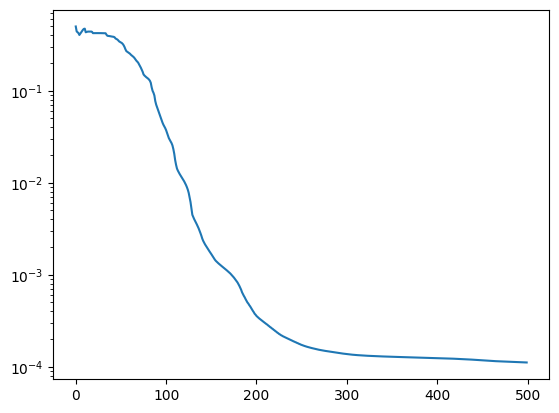

In [35]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewtonNew(model, lr=1e-1, config=config)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(500)):
    optimizer.zero_grad()

    # if i == 201:
    #     loss_weights = {"interface": 1.0, "eikonal": 0.001, "mean_curvature": 1.0}
    #     config["loss_weights"] = loss_weights
    #     config["regularization"] = 1e-4
    #     optim.config = config
        

    loss_interface  = 0.5*model.f(params, pts).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()
    loss_normal = 0.5*model.r_normal(params, pts_surface, true_normals).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["normal"] * loss_normal
    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_normal
        loss_over_iters[i] = loss_metric.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Normal: {loss_normal.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [ ]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewton(model, lr=1e-2, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    optimizer.zero_grad()

    loss_interface  = 0.5*model.f(params, pts_surface_original).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()

    # pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_eikonal) 
    config["pts_surface"] = pts_surface
    optimizer.config = config
    loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["mean_curvature"] * loss_mean_curvature
    loss.backward()
    with torch.no_grad():
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [36]:
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=pts.min(dim=0).values-0.01,
    bbox_max=pts.max(dim=0).values+0.15,
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
# fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewton(model, lr=1e-2, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(1000)):
    optimizer.zero_grad()

    loss_interface  = 0.5*model.f(params, pts_surface_original).square().mean()
    loss_eikonal  = 0.5*model.r_eikonal(params, pts_eikonal).squeeze(1).square().mean()

    # pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
    pts_surface = sample_model_surface_newton(model, pts_eikonal) 
    config["pts_surface"] = pts_surface
    optimizer.config = config
    loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["mean_curvature"] * loss_mean_curvature
    loss.backward()
    with torch.no_grad():
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Interface: {loss_interface.item():.2e} "
                             f"Eikonal: {loss_eikonal.item():.2e} "
                             f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [94]:
verts, faces = get_mesh(
    model.eval().float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1-2): 2 x Linear(in_features=32, out_features=32, bias=True)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [5]:
# Gauss-Newton weights:
loss_weights = {"interface": 1.0, "mean_curvature": 1.0}

pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
# pts_surface_original = pts_surface
# pts_eikonal = 2 * torch.rand([500, 3], dtype=torch.float64) - 1

config = {
    "pts_boundary": pts_surface_original,
    # "pts_eikonal": pts_eikonal,
    "pts_surface": pts_surface,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

  0%|          | 0/5 [00:00<?, ?it/s]

/cluster/software/stacks/2024-05/python-cuda/3.11.6/lib/python3.11/site-packages/torch/autograd/graph.py:744: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


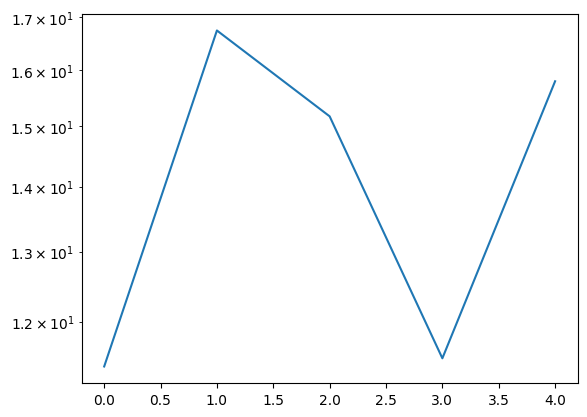

In [6]:
model = model.double()
params = model.params
loss_over_iters = {}
# Gauss-Newton:
optimizer = GaussNewtonWoodburyBig(model, lr=1e-1, config=config)
# Adam:
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
for i in (pbar:=trange(5)):
    optimizer.zero_grad()
    
    with torch.no_grad():
    
        pts_surface = sample_model_surface_binsearch(model, torch.rand([0, 3], dtype=torch.float64), bound_limit=1)
        pts_surface = sample_model_surface_newton(model, pts_surface) 
        config["pts_surface"] = pts_surface
        optimizer.config = config
        
        loss_mean_curvature = 0.5*model.r_mean_curvature(params, pts_surface).squeeze(1).square().mean()
        loss = loss_weights["mean_curvature"] * loss_mean_curvature
        loss_over_iters[i] = loss.item()
        pbar.set_description(f"Mean Curvature: {loss_mean_curvature.item():.2e} "
                             f"{len(pts_surface)}")
    optimizer.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [7]:
verts, faces = get_mesh(
    model.eval().float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()
model.double()

Output()

PlaceholderNet(
  (fcs): ModuleList(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)